In [1]:
import scanpy as sc
import anndata as ad
from scipy import stats
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import matplotlib as mpl
from scipy.stats import entropy
import mygene
from collections import defaultdict
from icepop.data import HomologyData
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA

# load data

In [2]:
# load
adata = sc.read('../data/TM_FACS/TM_FACS_normed.h5ad')
adata.obs['metacell'] = pd.read_csv('../results/TM_FACS_mc-75/mc_assign.csv', header=None, index_col=None)[0].values

In [3]:
# convert mouse to human genes
ortho_map = HomologyData(sp='mmusculus').load()
m2h = {}
for h, m in ortho_map.items():
    for i in m:
        m2h[i] = h

adata.var['hentrez'] = [m2h[i] if i in m2h else None for i in adata.var_names]
entrezid = adata.var['hentrez'][~pd.isna(adata.var['hentrez'])].values

mg = mygene.MyGeneInfo()
res = mg.querymany(
    entrezid,
    scopes="entrezgene",
    fields="symbol",
    species="human"
)

entrez_to_symbol = {
    r["query"]: r.get("symbol", None)
    for r in res
}
adata.var['hsymbol'] = [entrez_to_symbol[i] if i in entrez_to_symbol else None for i in adata.var['hentrez']]

adata = adata[:, ~pd.isna(adata.var['hsymbol'])].copy()
adata.var_names = adata.var['hsymbol']

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


In [4]:
trait_df = pd.read_csv('../data/TM_FACS/trait_name_map.tsv', header=0, index_col=0, sep='\t')
trait_df = trait_df[trait_df['include'] == 'Yes']
traits = trait_df.index.values
short_names = trait_df['trait_short_name'].values

In [5]:
indir = '../results/TM_icepop_mc-75'

# load metacell betas
files = Path(indir).glob('metacell__trait*.csv')
files = [str(i) for i in files]

icepop_df = []
for file in files:
    trait = Path(file).stem.split('__trait-')[1]
    df = pd.read_csv(file, header=0, index_col=None)
    df = df.loc[:, ['metacell', 'z']].set_index('metacell')
    df = df.rename(columns={'z': trait})
    icepop_df.append(df)
icepop_df = pd.concat(icepop_df, axis=1)
icepop_df = icepop_df.T

In [6]:
metacells = np.asarray(icepop_df.columns)
icepop_df = icepop_df.loc[traits, :].copy()

# Clustering disease based on Euclidean distance

In [7]:
def clustering(
    betas, Sigma_inv,
    k=5, resolution=1,
    random_state=1,
):
    """
    Spectral clustering using Mahalanobis-based similarity
    """
    n_diseases = betas.shape[0]
    
    # ------------------------------------------------------------
    # 1. Compute distances
    # ------------------------------------------------------------
    D2 = np.zeros((n_diseases, n_diseases))
    
    for i in range(n_diseases):
        for j in range(i+1, n_diseases):
            diff = betas[i] - betas[j]
            d2 = np.sum(diff ** 2)
            D2[i, j] = d2
            D2[j, i] = d2
    np.fill_diagonal(D2, 0.0)

    # ------------------------------------------------------------
    # 2. Build k-NN graph (based on distances)
    # ------------------------------------------------------------
    idx = np.argsort(D2, axis=1)[:, 1:k+1]   # skip itself

    # weighted adjacency matrix
    W = np.zeros_like(D2)

    # ------------------------------------------------------------
    # 3. Smooth neighbors by Gaussian kernel
    # ------------------------------------------------------------

    # use median heuristic for sigma^2
    sigma2 = np.median(D2[D2 > 0])

    for i in range(n_diseases):
        for j in idx[i]:
            w = np.exp(-D2[i, j] / (2 * sigma2))
            W[i, j] = w
            W[j, i] = w  # symmetrize

    # ------------------------------------------------------------
    # 4. Build weighted graph + run Louvain
    # ------------------------------------------------------------
    # create graph from weighted adjacency matrix
    G = nx.from_numpy_array(W)

    # remove self-loops and zero-weight edges
    G.remove_edges_from([
        (u, v) for u, v, w in G.edges(data="weight") if w == 0
    ])

    # run Louvain
    partition = nx.community.louvain_communities(
        G, weight='weight',
        resolution=resolution, seed=random_state
    )
    # initialize labels with -1
    labels = np.full(G.number_of_nodes(), -1, dtype=int)
    # assign community id
    for cid, community in enumerate(partition):
        for node in community:
            labels[node] = cid
    return labels, W, D2


def plot_knn_graph(
    W, names,
    labels=None, node_size=400,
    figsize=(8, 9), random_state=42
):
    """
    Plot weighted kNN graph W with node labels from names list,
    and add legends for edge and node colors.
    """

    # build graph
    G = nx.from_numpy_array(W)

    # remove zero-weight edges
    G.remove_edges_from([(u,v) for u,v,w in G.edges(data='weight') if w == 0])

    plt.figure(figsize=figsize)
    
    # layout (weighted spring)
    pos = nx.spring_layout(G, weight='weight', seed=random_state)

    # ===========================
    # NODE COLORS
    # ===========================
    if labels is not None:
        node_color = labels
        node_cmap = plt.cm.tab10
        unique_labels = sorted(set(labels))
    else:
        node_color = 'skyblue'
        node_cmap = None

    # draw nodes
    nodes = nx.draw_networkx_nodes(
        G, pos,
        node_size=node_size,
        node_color=node_color,
        cmap=node_cmap,
        edgecolors='black'
    )

    # ===========================
    # EDGE COLORS
    # ===========================
    weights = nx.get_edge_attributes(G, 'weight')
    edges, w = zip(*weights.items())

    edge_plot = nx.draw_networkx_edges(
        G, pos,
        edgelist=edges,
        width=[4*x for x in w],
        edge_color=w,
        edge_cmap=plt.cm.Blues,
        alpha=0.8,
    )

    # ===========================
    # NODE LABELS
    # ===========================
    for i, (x, y) in pos.items():
        plt.text(
            x + 0.01, y + 0.01, 
            names[i], fontsize=7
        )

    # ===========================
    # LEGEND: EDGE COLORBAR
    # ===========================
    sm = mpl.cm.ScalarMappable(
        cmap=plt.cm.Blues,
        norm=plt.Normalize(vmin=min(w), vmax=max(w))
    )
    sm._A = []  # necessary trick for old mpl versions

    ax = plt.gca()
    cbar = plt.colorbar(
        sm, 
        ax=ax,              # <-- important fix
        fraction=0.03, 
        pad=0.02
    )
    cbar.set_label("Edge Weight (Similarity)")

    # ===========================
    # CLEANUP AND SHOW
    # ===========================
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def quantile_normalize(X):
    """
    Quantile-normalize rows of a matrix (traits × genes).

    Parameters
    ----------
    X : np.ndarray, shape (n_traits, n_genes)
        Input matrix (e.g. MAGMA Z-scores).

    Returns
    -------
    X_qn : np.ndarray, same shape as X
        Quantile-normalized matrix.
    """

    X = np.asarray(X, dtype=float)

    # 1. sort each row
    X_sorted = np.sort(X, axis=1)

    # 2. compute mean quantile across cols
    mean_quantiles = X_sorted.mean(axis=0)

    # 3. get ranks within each row
    ranks = np.argsort(np.argsort(X, axis=1), axis=1)

    # 4. map ranks to mean quantiles
    X_qn = mean_quantiles[ranks]

    return X_qn

## Disease zscore based distance

In [8]:
# get zscore
files = Path('../data/magmaz').glob('*.genes.out')
z_dfs = []
for file in files:
    name = Path(file).name.replace('.genes.out', '')
    df = pd.read_csv(file, header=0, index_col=None, sep=r'\s+')
    df['GENE'] = df['GENE'].astype(str)
    df['trait'] = name
    z_dfs.append(df.loc[:, ['GENE', 'ZSTAT', 'trait']])
z_df = pd.concat(z_dfs)

# get shared genes across all triats
cnt = z_df['GENE'].value_counts()
z_shared_genes = cnt[cnt == 84].index.values

# get zscore mat
z_mat = {}
for df in z_dfs:
    df_indexed = df.set_index('GENE')
    z_mat[df_indexed['trait'].iloc[0]] = df_indexed.loc[z_shared_genes, 'ZSTAT']
z_mat = pd.DataFrame(z_mat)
z_mat = z_mat.loc[:, traits].copy()
z_mat = z_mat.T

# quantile normalize zscore
z_mat_norm = quantile_normalize(z_mat.to_numpy())

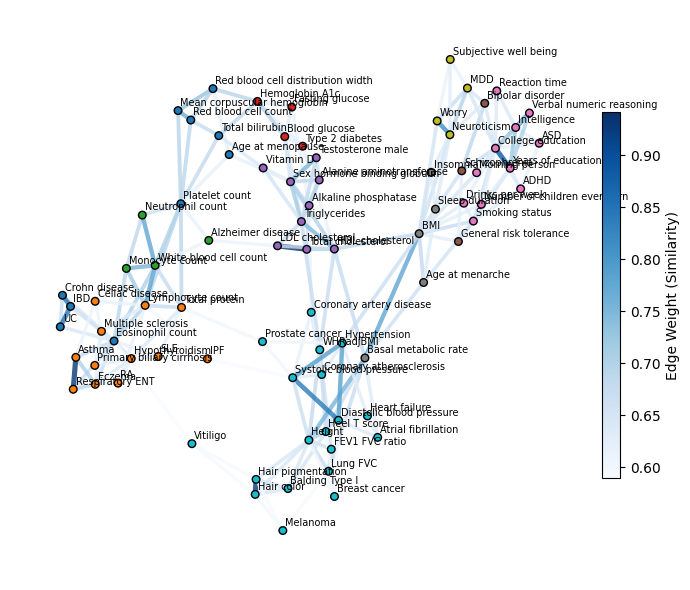

In [9]:
# clustering on euclidean distance without considering covar
labels, W, D2 = clustering(
    z_mat_norm, None,
    k=3, resolution=2.5, random_state=42
)

gwasz_W_df = pd.DataFrame(W, index=short_names, columns=short_names)
gwasz_clus_df = (
    gwasz_W_df
    .where(np.triu(np.ones(gwasz_W_df.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={
        'level_0': 'trait1',
        'level_1': 'trait2',
        0: 'simi'
    })
)

plot_knn_graph(W, short_names, labels=labels, node_size=30, figsize=(7, 6), random_state=1)

In [10]:
cluster_df = pd.DataFrame(zip(traits, short_names, labels), columns=['trait', 'short_name', 'cluster'])
cluster_df.to_csv('../paper/suppdata/dis_dis_sim_magma_clus.tsv', header=True, index=False, sep='\t')
cluster_df.sort_values(by='cluster')

,trait,short_name,cluster
5,UKB_460K.blood_PLATELET_COUNT,Platelet count,0
6,UKB_460K.blood_RBC_DISTRIB_WIDTH,Red blood cell distribution width,0
7,UKB_460K.blood_RED_COUNT,Red blood cell count,0
80,UKB_460K.repro_MENOPAUSE_AGE,Age at menopause,0
3,UKB_460K.blood_MEAN_CORPUSCULAR_HEMOGLOBIN,Mean corpuscular hemoglobin,0
...,...,...,...
70,UKB_460K.lung_FVCzSMOKE,Lung FVC,11
69,UKB_460K.lung_FEV1FVCzSMOKE,FEV1 FVC ratio,11
19,vitiligo,Vitiligo,11
72,melanoma,Melanoma,11


In [11]:
# remove self-loops (optional)
adj = pd.DataFrame(W, index=short_names, columns=short_names)

# remove self-loops (optional)
np.fill_diagonal(adj.values, 0)

# convert to edge list
edges = (
    adj
    .stack()
    .reset_index()
)

edges.columns = ["source", "target", "weight"]

# remove zero / NA edges
edges = edges.query("weight != 0")

# OPTIONAL: keep only upper triangle (undirected graph)
edges = edges[edges["source"] < edges["target"]]

# export
edges.to_csv("../paper/suppdata/cytoscape_edges_magma_W.tsv", sep="\t", index=False)

node_table = cluster_df.loc[:, ['short_name', 'cluster']].copy()
node_table.columns = ['node', 'cluster']
node_table.to_csv(
    "../paper/suppdata/cytoscape_nodes_magma.tsv",
    sep="\t",
    index=False
)

In [12]:
clus2name = defaultdict(list)
for name, clus in zip(cluster_df['short_name'], cluster_df['cluster']):
    clus2name[clus].append(name)
for clus, names in clus2name.items():
    print(','.join(names))

Neutrophil count,Monocyte count,White blood cell count,Alzheimer disease
Eosinophil count,UC,Crohn disease,IBD
Lymphocyte count,Celiac disease,SLE,Multiple sclerosis,Primary biliary cirrhosis,RA,Eczema,Hypothyroidism,Total protein,IPF,Asthma,Respiratory ENT
Mean corpuscular hemoglobin,Platelet count,Red blood cell distribution width,Red blood cell count,Total bilirubin,Age at menopause
Vitiligo,WHRadjBMI,FEV1 FVC ratio,Lung FVC,Hair color,Melanoma,Heel T score,Balding Type I,Height,Breast cancer,Hair pigmentation
Fasting glucose,Type 2 diabetes,Blood glucose,Hemoglobin A1c
Alanine aminotransferase,Alkaline phosphatase,Total cholesterol,HDL cholesterol,LDL cholesterol,Sex hormone binding globulin,Testosterone male,Triglycerides,Vitamin D
Basal metabolic rate,BMI,Insomnia,Sleep duration,Age at menarche
ASD,ADHD,Intelligence,Reaction time,Verbal numeric reasoning,Morning person,Drinks per week,College education,Years of education,Smoking status,Number of children ever born
Bipolar disorde

In [13]:
# Neutrophil count,Monocyte count,White blood cell count,Alzheimer disease
# Eosinophil count,UC,Crohn disease,IBD
# Lymphocyte count,Celiac disease,SLE,Multiple sclerosis,Primary biliary cirrhosis,RA,Eczema,Hypothyroidism,Total protein,IPF,Asthma,Respiratory ENT
# Mean corpuscular hemoglobin,Platelet count,Red blood cell distribution width,Red blood cell count,Total bilirubin,Age at menopause
# Vitiligo,WHRadjBMI,FEV1 FVC ratio,Lung FVC,Hair color,Melanoma,Heel T score,Balding Type I,Height,Breast cancer,Hair pigmentation
# Fasting glucose,Type 2 diabetes,Blood glucose,Hemoglobin A1c
# Alanine aminotransferase,Alkaline phosphatase,Total cholesterol,HDL cholesterol,LDL cholesterol,Sex hormone binding globulin,Testosterone male,Triglycerides,Vitamin D
# Basal metabolic rate,BMI,Insomnia,Sleep duration,Age at menarche
# ASD,ADHD,Intelligence,Reaction time,Verbal numeric reasoning,Morning person,Drinks per week,College education,Years of education,Smoking status,Number of children ever born
# Bipolar disorder,General risk tolerance,Schizophrenia
# MDD,Subjective well being,Worry,Neuroticism
# Coronary atherosclerosis,Heart failure,Atrial fibrillation,Coronary artery disease,Diastolic blood pressure,Systolic blood pressure,Hypertension,Prostate cancer

## metacell association based distance

In [14]:
pca = PCA(n_components=50, svd_solver="full")
X_pc = pca.fit_transform(icepop_df.values)
pc_df = pd.DataFrame(
    X_pc,
    index=icepop_df.index,
    columns=[f"PC{i+1}" for i in range(X_pc.shape[1])]
)

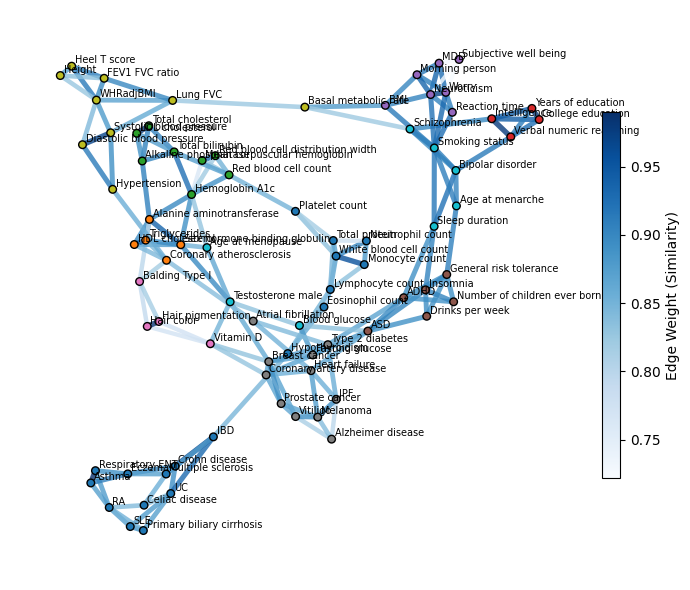

In [15]:
# clustering on euclidean distance without considering covar
labels, W, D2 = clustering(
    pc_df.to_numpy(), None,
    k=3, resolution=2.5, random_state=42
)

mc_W_df = pd.DataFrame(W, index=short_names, columns=short_names)
mc_clus_df = (
    mc_W_df
    .where(np.triu(np.ones(mc_W_df.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={
        'level_0': 'trait1',
        'level_1': 'trait2',
        0: 'simi'
    })
)

plot_knn_graph(W, short_names, labels=labels, node_size=30, figsize=(7, 6), random_state=2)

In [16]:
cluster_df = pd.DataFrame(zip(traits, short_names, labels), columns=['trait', 'short_name', 'cluster'])
cluster_df.to_csv('../paper/suppdata/dis_dis_sim_metacell_clus.tsv', header=True, index=False, sep='\t')
cluster_df.sort_values(by='cluster')

,trait,short_name,cluster
0,neutrophil_count,Neutrophil count,0
18,UKB_460K.disease_HYPOTHYROIDISM_SELF_REP,Hypothyroidism,0
32,UKB_460K.biochemistry_TotalProtein,Total protein,0
8,UKB_460K.blood_WHITE_COUNT,White blood cell count,0
1,UKB_460K.blood_EOSINOPHIL_COUNT,Eosinophil count,0
...,...,...,...
48,PASS_SleepDuration_Dashti2019,Sleep duration,10
57,UKB_460K.cov_SMOKING_STATUS,Smoking status,10
80,UKB_460K.repro_MENOPAUSE_AGE,Age at menopause,11
25,UKB_460K.biochemistry_Glucose,Blood glucose,11


In [17]:
# remove self-loops (optional)
adj = pd.DataFrame(W, index=short_names, columns=short_names)

# remove self-loops (optional)
np.fill_diagonal(adj.values, 0)

# convert to edge list
edges = (
    adj
    .stack()
    .reset_index()
)

edges.columns = ["source", "target", "weight"]

# remove zero / NA edges
edges = edges.query("weight != 0")

# OPTIONAL: keep only upper triangle (undirected graph)
edges = edges[edges["source"] < edges["target"]]

# export
edges.to_csv("../paper/suppdata/cytoscape_edges_metacell_W.tsv", sep="\t", index=False)

node_table = cluster_df.loc[:, ['short_name', 'cluster']].copy()
node_table.columns = ['node', 'cluster']
node_table.to_csv(
    "../paper/suppdata/cytoscape_nodes_metacell.tsv",
    sep="\t",
    index=False
)

In [18]:
clus2name = defaultdict(list)
for name, clus in zip(cluster_df['short_name'], cluster_df['cluster']):
    clus2name[clus].append(name)
for clus, names in clus2name.items():
    print(','.join(names))

Neutrophil count,Eosinophil count,Lymphocyte count,Monocyte count,Platelet count,White blood cell count,Hypothyroidism,Total protein
Mean corpuscular hemoglobin,Red blood cell distribution width,Red blood cell count,Alkaline phosphatase,Total cholesterol,Hemoglobin A1c,LDL cholesterol,Total bilirubin
UC,Crohn disease,Celiac disease,IBD,SLE,Multiple sclerosis,Primary biliary cirrhosis,RA,Eczema,Asthma,Respiratory ENT
Vitiligo,Fasting glucose,Type 2 diabetes,Alzheimer disease,Heart failure,Atrial fibrillation,Coronary artery disease,IPF,Melanoma,Prostate cancer,Breast cancer
Alanine aminotransferase,HDL cholesterol,Sex hormone binding globulin,Triglycerides,Coronary atherosclerosis
Blood glucose,Testosterone male,Age at menopause
WHRadjBMI,Basal metabolic rate,Systolic blood pressure,Diastolic blood pressure,Hypertension,FEV1 FVC ratio,Lung FVC,Heel T score,Height
Vitamin D,Hair color,Balding Type I,Hair pigmentation
BMI,MDD,Reaction time,Subjective well being,Worry,Neuroticism,Morning p

## separation of leukocyte count trait and autoimmune disease

In [19]:
leu_triats = cluster_df[cluster_df['cluster'] == 0]['trait'].values
auto_triats = cluster_df[cluster_df['cluster'] == 1]['trait'].values
foc_traits = np.concatenate([leu_triats, auto_triats])

icepop_ct_df = []
for trait in foc_traits:
    df = pd.read_csv(f'{indir}/celltype__trait-{trait}.csv', header=0, index_col=None)
    df['trait'] = trait
    icepop_ct_df.append(df)
icepop_ct_df = pd.concat(icepop_ct_df, axis=0, ignore_index=True)

# trait
trait_name_df = pd.read_csv('../data/TM_FACS/trait_name_map.tsv', header=0, index_col=0, sep='\t')
# cell type
ct_name_df = pd.read_csv('../data/TM_FACS/celltype_name_map.tsv', header=0, index_col=0, sep='\t')

In [20]:
cell_types_ordered = [
    # Blood progenitor
    "Hematopoietic stem cell",
    "Granulocyte monocyte progenitor cell",
    "Megakaryocyte-erythroid progenitor cell",
    "Granulocytopoietic cell",
    "Proerythroblast",
    "Late pro-B cell",
    "Precursor B cell",
    "Immature B cell",
    "Thymocyte",
    "DN4 thymocyte",

    # Vascular
    "Endothelial cell",
    "Aortic endothelial cell",
    "Vein endothelial cell",
    "Capillary endothelial cells",
    "Endothelial cell of coronary artery",
    "Endothelial cell of hepatic sinusoid",
    "Fenestrated cell",
    "Smooth muscle cell of the pulmonary artery",
    "Valve cell",

    # Myeloid
    "Monocyte",
    "Classical monocyte",
    "Non-classical monocyte",
    "Promonocyte",
    "Macrophage",
    "Kupffer cell",
    "Microglial cell",
    "Dendritic cell",
    "Myeloid dendritic cell",
    "Neutrophil",
    "Granulocyte",
    "Basophil",
    "Myeloid cell",
    "Myeloid leukocyte",
    "Leukocyte",

    # Lymphocytes
    "B cell",
    "Naive B cell",
    "CD4-positive, alpha-beta T cell",
    "CD8-positive, alpha-beta T cell",
    "Mature alpha-beta T cell",
    "T cell",
    "NK cell",
    "Mature NK T cell",

    # Epithelial / epidermal
    "Epithelial cell",
    "Epidermal cell",
    "Basal cell of epidermis",

    # Mesenchymal / muscle
    "Mesenchymal stem cell of adipose",
    "Atrial myocyte",

    # Other
    "Intestinal crypt stem cell",
]

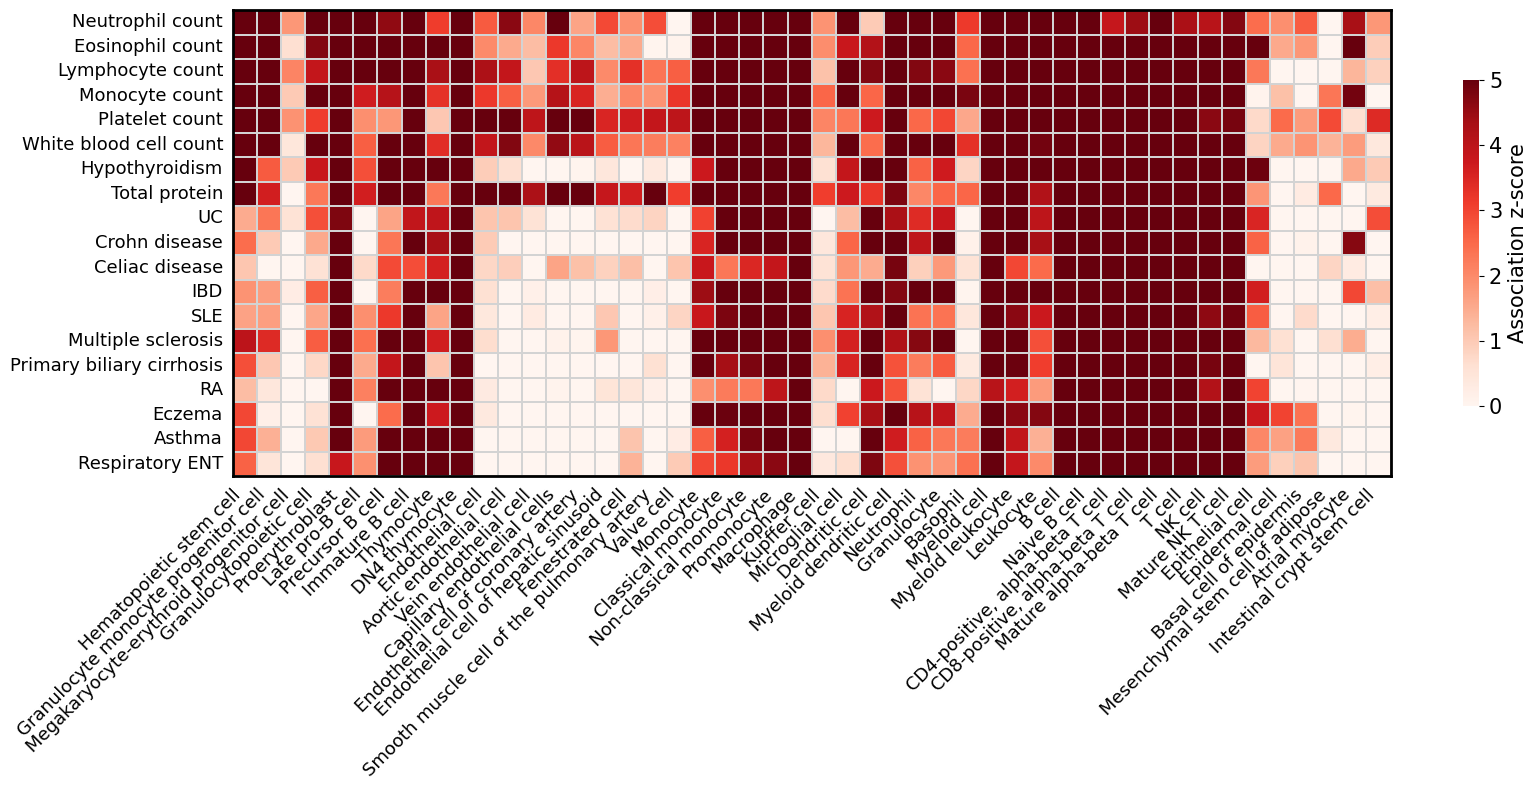

In [21]:
pivot_df = icepop_ct_df.pivot(index='trait', columns='cell_type', values='z')
pivot_df = pivot_df.loc[foc_traits, :].copy()
pivot_df = pivot_df.fillna(0)
pivot_df.index = trait_name_df.loc[pivot_df.index, 'trait_short_name'].values
pivot_df.columns = ct_name_df.loc[pivot_df.columns, 'name'].values
pivot_df = pivot_df.loc[:, (pivot_df >= 1.5).sum(0) > 2]
pivot_df = pivot_df.loc[:, cell_types_ordered]

fig, ax = plt.subplots(figsize=(17, 8))
hm = sns.heatmap(
    pivot_df,
    linewidths=0.01,
    linecolor='lightgrey',
    cmap='Reds', vmin=0, vmax=5, ax=ax, cbar_kws={"shrink": 0.7},
)

ax.tick_params(left=False, bottom=False)

# make legend (colorbar) smaller
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=15)
cbar.set_label('Association z-score', fontsize=15)
cbar.ax.set_position([0.76, 0.4, 0.1, 0.3])

# Thicken the outer border (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.0)   # thicker border

ax.set_xticklabels(pivot_df.columns, rotation=45, ha='right', fontsize=13)
ax.set_yticklabels(pivot_df.index, fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig("../paper/main/graph_comp_blood_autoimmune.pdf", bbox_inches="tight")

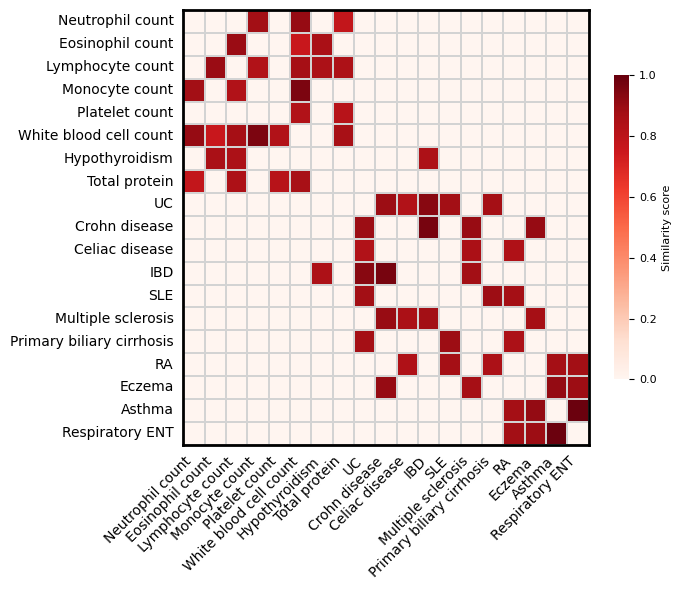

In [22]:
fig, ax = plt.subplots(figsize=(7.1, 6))
hm = sns.heatmap(
    mc_W_df.loc[pivot_df.index, pivot_df.index],
    cmap='Reds', linewidths=0.01, linecolor='lightgrey', ax=ax, cbar_kws={"shrink": 0.7},
    vmin=0.0, vmax=1.0
)

# make legend (colorbar) smaller
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Similarity score', fontsize=8)

ax.set_xticklabels(pivot_df.index, rotation=45, ha='right')
ax.set_yticklabels(pivot_df.index)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(left=False, bottom=False)

# Thicken the outer border (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.0)   # thicker border

plt.tight_layout()
plt.savefig("../paper/main/graph_comp_blood_autoimmune_mcw.pdf", bbox_inches="tight")

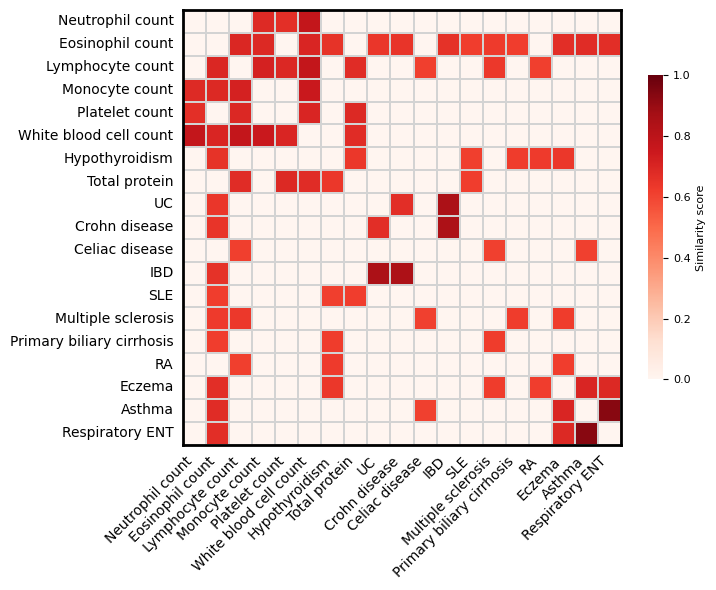

In [23]:
fig, ax = plt.subplots(figsize=(7.5, 6))
hm = sns.heatmap(
    gwasz_W_df.loc[pivot_df.index, pivot_df.index],
    cmap='Reds', linewidths=0.01, linecolor='lightgrey', ax=ax, cbar_kws={"shrink": 0.7},
    vmin=0.0, vmax=1.0
)

# make legend (colorbar) smaller
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Similarity score', fontsize=8)

ax.set_xticklabels(pivot_df.index, rotation=45, ha='right')
ax.set_yticklabels(pivot_df.index)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(left=False, bottom=False)

# Thicken the outer border (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.0)   # thicker border

plt.tight_layout()
plt.savefig("../paper/main/graph_comp_blood_autoimmune_gwasw.pdf", bbox_inches="tight")

## separation of hair related traits

In [24]:
hair_triats = ['UKB_460K.body_BALDING1', 'hair_color', 'UKB_460K.pigment_HAIR']
pigment_triats = ['melanoma', 'vitiligo']
foc_traits = np.concatenate([hair_triats, pigment_triats])

icepop_ct_df = []
for trait in foc_traits:
    df = pd.read_csv(f'{indir}/celltype__trait-{trait}.csv', header=0, index_col=None)
    df['trait'] = trait
    icepop_ct_df.append(df)
icepop_ct_df = pd.concat(icepop_ct_df, axis=0, ignore_index=True)

In [25]:
cell_types_ordered = [
    # Keratinocyte / epidermal–related
    "Bulge keratinocyte",
    "Keratinocyte",
    "Keratinocyte stem cell",
    "Basal cell",
    "Basal cell of epidermis",
    "Epidermal cell",

    # Endothelial/Epithelial cells
    "Endothelial cell",
    "Epithelial cell",

    # Leukocytes
    "Immature B cell",
    "B cell",
    "Naive B cell",
    "Macrophage",
    "Non-classical monocyte",
    "T cell",
    "CD4-positive, alpha-beta T cell",
    "CD8-positive, alpha-beta T cell",
    "Mature alpha-beta T cell",
    "DN4 thymocyte",
    "NK cell",
]

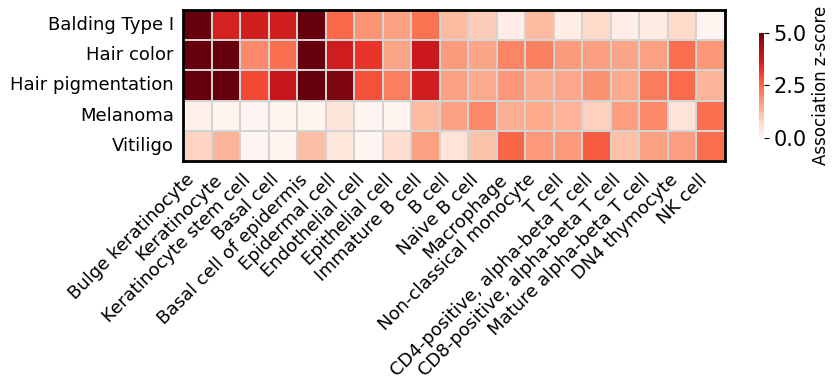

In [26]:
pivot_df = icepop_ct_df.pivot(index='trait', columns='cell_type', values='z')
pivot_df = pivot_df.loc[foc_traits, :].copy()
pivot_df = pivot_df.fillna(0)
pivot_df.index = trait_name_df.loc[pivot_df.index, 'trait_short_name'].values
pivot_df.columns = ct_name_df.loc[pivot_df.columns, 'name'].values
pivot_df = pivot_df.loc[:, (pivot_df >= 1.5).sum(0) > 2]
pivot_df = pivot_df.loc[:, cell_types_ordered]

fig, ax = plt.subplots(figsize=(8.8, 4))
hm = sns.heatmap(
    pivot_df,
    linewidths=0.01,
    linecolor='lightgrey',
    cmap='Reds', vmin=0, vmax=5, ax=ax, cbar_kws={"shrink": 0.7},
)

ax.tick_params(left=False, bottom=False)

# make legend (colorbar) smaller
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=15)
cbar.set_label('Association z-score', fontsize=12)
cbar.ax.set_position([0.76, 0.4, 0.1, 0.3])

# Thicken the outer border (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.0)   # thicker border

ax.set_xticklabels(pivot_df.columns, rotation=45, ha='right', fontsize=13)
ax.set_yticklabels(pivot_df.index, fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig("../paper/main/graph_comp_hair_cell.pdf", bbox_inches="tight")

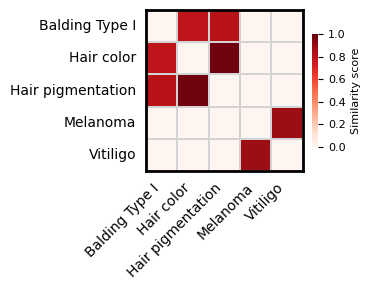

In [27]:
fig, ax = plt.subplots(figsize=(3.7, 3))
hm = sns.heatmap(
    mc_W_df.loc[pivot_df.index, pivot_df.index],
    cmap='Reds', linewidths=0.01, linecolor='lightgrey', ax=ax,
    vmin=0.0, vmax=1.0, cbar_kws={"shrink": 0.7},
)

# make legend (colorbar) smaller
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Similarity score', fontsize=8)

ax.set_xticklabels(pivot_df.index, rotation=45, ha='right')
ax.set_yticklabels(pivot_df.index)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(left=False, bottom=False)

# Thicken the outer border (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.0)   # thicker border

plt.tight_layout()
plt.savefig("../paper/main/graph_comp_hair_cell_mcw.pdf", bbox_inches="tight")

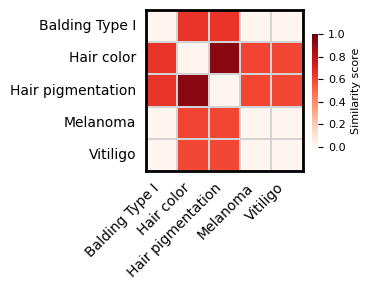

In [28]:
fig, ax = plt.subplots(figsize=(3.7, 3))
hm = sns.heatmap(
    gwasz_W_df.loc[pivot_df.index, pivot_df.index],
    cmap='Reds', linewidths=0.01, linecolor='lightgrey', ax=ax,
    vmin=0.0, vmax=1.0, cbar_kws={"shrink": 0.7},
)

# make legend (colorbar) smaller
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Similarity score', fontsize=8)

ax.set_xticklabels(pivot_df.index, rotation=45, ha='right')
ax.set_yticklabels(pivot_df.index)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(left=False, bottom=False)

# Thicken the outer border (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.0)   # thicker border

plt.tight_layout()
plt.savefig("../paper/main/graph_comp_hair_cell_gwasw.pdf", bbox_inches="tight")